In [1]:
# ORIGINAL ENVIRONMENT: Google Colab
# CONVERTED FOR: Local Python 3.13

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
# !pip install catboost
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "collision_severity"

# 1.Load data
df = pd.read_csv("dataset/UK_accidents_balanced.csv")
print(f"Loaded data: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Shuffle toàn bộ dataset
df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 2. Drop columns that either identify the record or leak the target
leak_cols = [
    "enhanced_severity_collision",
    "collision_injury_based",
    "collision_adjusted_severity_serious",
    "collision_adjusted_severity_slight",
]
id_cols = [
    "collision_index", "collision_ref_no", "date", "time",
    "local_authority_ons_district", "local_authority_highway",
    "local_authority_highway_current", "lsoa_of_accident_location",
]

drop_cols = leak_cols + id_cols
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])

# 3. Handle missing values

num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove(TARGET)
cat_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())
for c in cat_cols:
    df_model[c] = df_model[c].fillna("missing")

# 4. Encode remaining categorical columns

for c in cat_cols:
    df_model[c] = LabelEncoder().fit_transform(df_model[c].astype(str))


# 4b. Gộp nhãn: 2,3 -> 0 (chỉ giữ 1 = Fatal, còn lại = 0)

df_model[TARGET] = df_model[TARGET].replace({2: 0, 3: 0})
print("Phân bố nhãn sau khi gộp:")
print(df_model[TARGET].value_counts())


# 5. Train / test split

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")


# 6. Train Models

# Logistic Regression
model1 = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)
model1.fit(X_train, y_train)

# Random Forest
model2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
model2.fit(X_train, y_train)

# XGBoost
model3 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
model3.fit(X_train, y_train)

# LightGBM
model4 = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=10,
    class_weight="balanced",
    random_state=42
)
model4.fit(X_train, y_train)

# CatBoost
model5 = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="F1",
    verbose=False,
    random_seed=42
)
model5.fit(X_train, y_train)


# 7. Evaluate

models = {
    "Logistic Regression": model1,
    "Random Forest": model2,
    "XGBoost": model3,
    "LightGBM": model4,
    "CatBoost": model5
}

for name, model in models.items():

    print("\n" + "=" * 60)
    print(f"{name} RESULTS")
    print("=" * 60)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")

    print(f"Accuracy   : {acc:.4f}")
    print(f"F1 Macro   : {f1_macro:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Non-Fatal (0)", "Fatal (1)"]
    ))

    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    print(cm)

    # Feature Importance
    if hasattr(model, "feature_importances_"):

      print("\nTop 15 Feature Importances:")

      importance = pd.Series(
        model.feature_importances_,
        index=X.columns
      ).sort_values(ascending=False)

      print(importance.head(15))
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1 Macro": f1_score(y_test, y_pred, average="macro")
    })

results = pd.DataFrame(results)

print("\nModel Comparison")
print(results.sort_values("F1 Macro", ascending=False))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.3 MB/s eta 0:00:00
Loaded data: 289,444 rows x 44 columns
Phân bố nhãn sau khi gộp:
collision_severity
1    144722
0    144722
Name: count, dtype: int64
Train: 231,555 rows | Test: 57,889 rows


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Info] Number of positive: 115778, number of negative: 115777
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.034704 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2111
[LightGBM] [Info] Number of data points in the train set: 231555, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

Logistic Regression RESULTS
Accuracy   : 0.6752
F1 Macro   : 0.6750

Classification Report:
               precision    recall  f1-score   support

Non-Fatal (0)       0.67      0.70      0.68     28945
    Fatal (1)       0.68      0.65      0.67     28944

     accuracy                           0.68     57889
    macro avg       0.68      0.68      0.68     57889
 weighted avg       0.68      0.68      0.68     57889

Confusion Matri

# 🧪 Machine Learning Experiments

This section extends the baseline pipeline above with a full experimental study:

1. **Part 1 — Baseline & Advanced Models**: 9 classifiers commonly used in accident-severity literature, evaluated under one unified protocol.
2. **Part 2 — Improved CatBoost with Spatial Feature Engineering**: a spatially-aware CatBoost model built from `latitude` / `longitude`.
3. **Part 3 — Ablation Study**: isolates the contribution of spatial features vs. CatBoost-specific training improvements.
4. **Part 4 — Visualization**: feature importance, SHAP, ROC/PR curves, confusion matrix, and a spatial cluster map.
5. **Part 5 — Discussion**: a paper-style write-up of the findings.

All experiments reuse `X_train`, `X_test`, `y_train`, `y_test`, `df`, `cat_cols` and `RANDOM_STATE` produced by the preprocessing pipeline above, so results stay directly comparable and no existing code is modified.


## Part 0 — Exploratory Data Analysis

Before modeling, we characterize the dataset: how much data is missing, how the target is distributed, how key variables relate to fatality risk, and how accidents are distributed geographically. This uses the raw `df` (before the pipeline's imputation/encoding above), so categories and missing values are shown in their original, human-readable form.


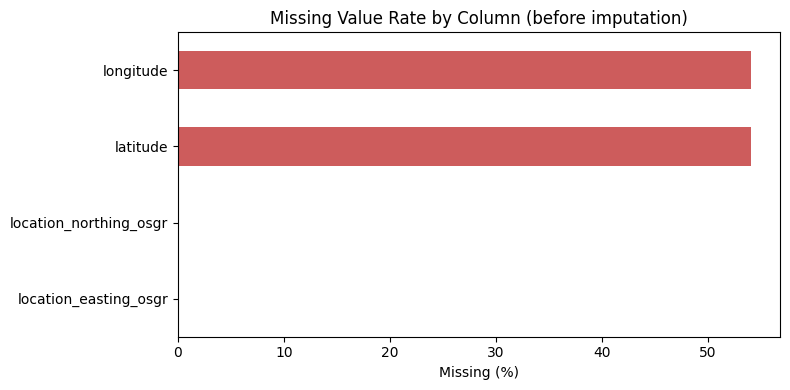

longitude                 54.096820
latitude                  54.096820
location_northing_osgr     0.134396
location_easting_osgr      0.134396
dtype: float64


In [5]:
import matplotlib.pyplot as plt
# --- Missing value rates (computed on the untouched `df`, before the pipeline's fillna) ---
missing_rates = (df[df_model.columns].isna().mean() * 100).sort_values(ascending=False)
missing_rates = missing_rates[missing_rates > 0]

fig, ax = plt.subplots(figsize=(8, max(4, len(missing_rates) * 0.3)))
missing_rates.sort_values().plot.barh(ax=ax, color="indianred")
ax.set_xlabel("Missing (%)")
ax.set_title("Missing Value Rate by Column (before imputation)")
plt.tight_layout()
plt.show()

print(missing_rates)


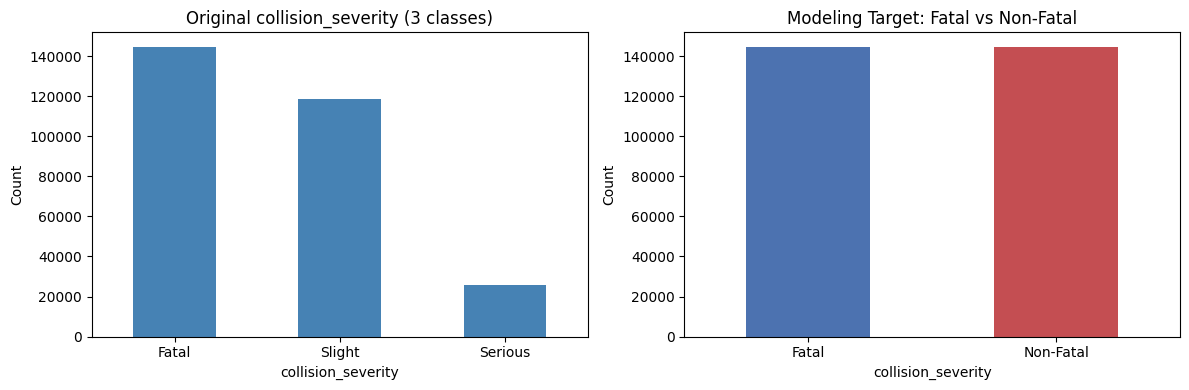

Modeling target proportions:
collision_severity
1    0.5
0    0.5
Name: proportion, dtype: float64


In [6]:
# --- Target distribution: original 3-class severity vs. the binary Fatal/Non-Fatal modeling target ---
severity_labels = {1: "Fatal", 2: "Serious", 3: "Slight"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df[TARGET].map(severity_labels).value_counts().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Original collision_severity (3 classes)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y.map({0: "Non-Fatal", 1: "Fatal"}).value_counts().plot.bar(ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Modeling Target: Fatal vs Non-Fatal")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Modeling target proportions:")
print(y.value_counts(normalize=True).rename("proportion"))


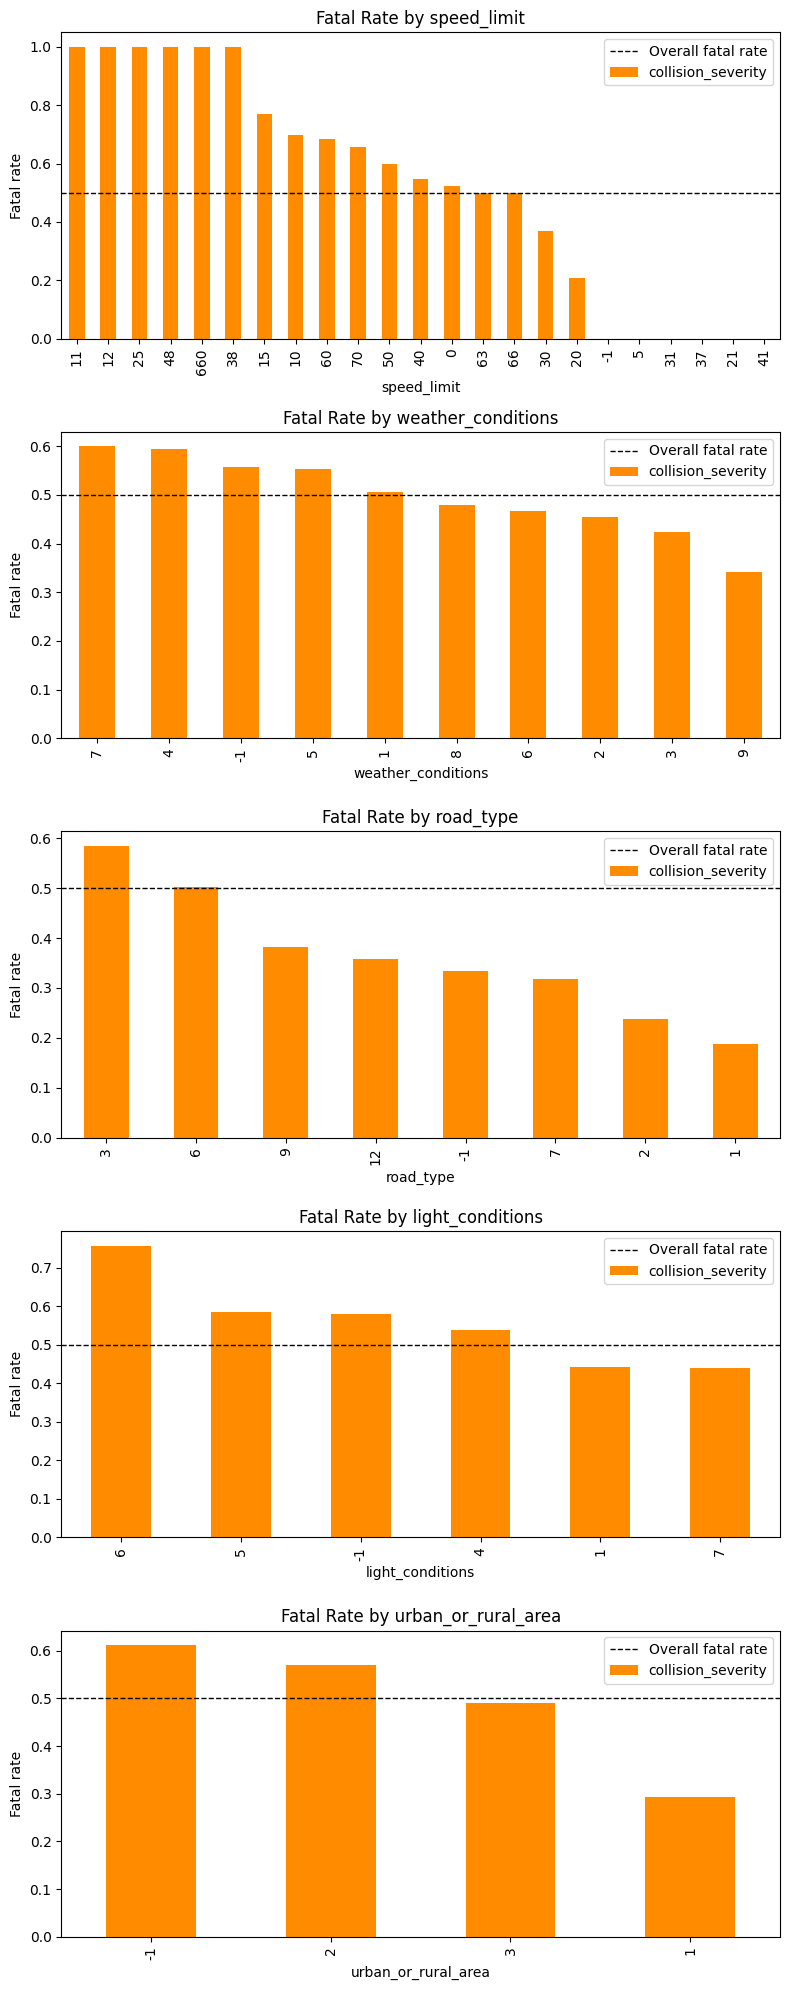

In [7]:
# --- Fatal rate by key variables (original, human-readable categories from `df`) ---
key_vars = ["speed_limit", "weather_conditions", "road_type", "light_conditions", "urban_or_rural_area"]
overall_fatal_rate = (df[TARGET] == 1).mean()

fig, axes = plt.subplots(len(key_vars), 1, figsize=(8, 4 * len(key_vars)))
for ax, col in zip(axes, key_vars):
    rate = df.groupby(col)[TARGET].apply(lambda s: (s == 1).mean()).sort_values(ascending=False)
    rate.plot.bar(ax=ax, color="darkorange")
    ax.set_title(f"Fatal Rate by {col}")
    ax.set_ylabel("Fatal rate")
    ax.axhline(overall_fatal_rate, color="black", linestyle="--", linewidth=1, label="Overall fatal rate")
    ax.legend()

plt.tight_layout()
plt.show()


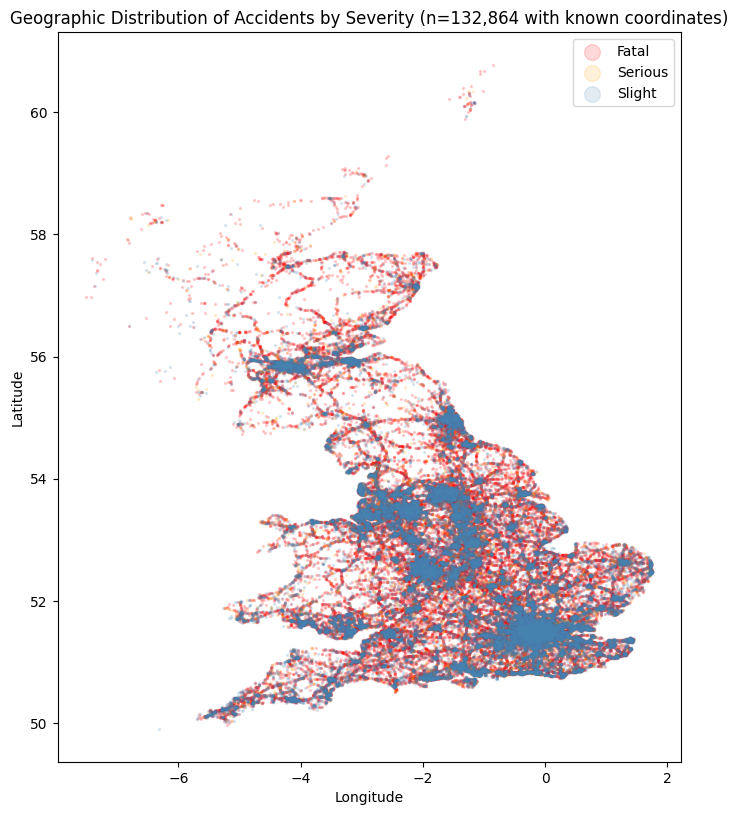

In [8]:
# --- Geographic distribution of accidents by severity (raw lat/lon, before imputation) ---
geo = df[["latitude", "longitude", TARGET]].dropna()

fig, ax = plt.subplots(figsize=(7, 9))
for sev, color, label in [(1, "red", "Fatal"), (2, "orange", "Serious"), (3, "steelblue", "Slight")]:
    subset = geo[geo[TARGET] == sev]
    ax.scatter(subset["longitude"], subset["latitude"], s=2, alpha=0.15, color=color, label=label)

ax.set_title(f"Geographic Distribution of Accidents by Severity (n={len(geo):,} with known coordinates)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()


## Part 1 — Baseline & Advanced Machine Learning Models

Traffic-accident severity/fatality studies in the literature most commonly benchmark tree-ensemble and boosting methods against linear baselines. We evaluate **9 models**:

| Family | Model(s) |
|---|---|
| Linear | Logistic Regression |
| Single tree | Decision Tree |
| Bagging ensembles | Random Forest, Extra Trees |
| Classic boosting | AdaBoost, Gradient Boosting |
| Modern GBDT | XGBoost, LightGBM, CatBoost |

Every model is trained on the same `X_train`/`y_train` and evaluated on the same `X_test`/`y_test` produced by the preprocessing pipeline above, so the comparison is fair. A single reusable `train_and_evaluate()` function guarantees every model is measured with the same metrics: **Accuracy, Precision, Recall, F1-Score, ROC-AUC, Confusion Matrix, Training Time, Inference Time**.


In [9]:
# --- Additional imports for the extended ML section (Parts 1-5) ---
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve
)

sns.set_style("whitegrid")


def train_and_evaluate(name, model, X_tr, y_tr, X_te, y_te,
                        fit_kwargs=None, already_fitted=False, train_time=None):
    """
    Reusable train/evaluate routine shared by Part 1, Part 3 (ablation) and Part 4.

    If already_fitted=True, `model` is assumed pre-trained (used for the Improved
    CatBoost model, whose training involves early stopping / a validation set and
    therefore happens outside this helper) and `train_time` must be supplied.
    """
    fit_kwargs = fit_kwargs or {}

    if not already_fitted:
        start = time.time()
        model.fit(X_tr, y_tr, **fit_kwargs)
        train_time = time.time() - start

    start = time.time()
    y_pred = model.predict(X_te)
    inference_time = time.time() - start

    y_proba = (
        model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred
    )

    cm = confusion_matrix(y_te, y_pred, labels=[0, 1])

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred, zero_division=0),
        "Recall": recall_score(y_te, y_pred, zero_division=0),
        "F1-Score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "Training Time (s)": train_time,
        "Inference Time (s)": inference_time,
    }
    return metrics, model, y_pred, y_proba, cm


def print_model_report(name, metrics, cm):
    """Console report shared across all sections."""
    print("\n" + "=" * 60)
    print(f"{name} RESULTS")
    print("=" * 60)
    for k in ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]:
        print(f"{k:<12}: {metrics[k]:.4f}")
    print(f"{'Train Time':<12}: {metrics['Training Time (s)']:.2f}s")
    print(f"{'Infer Time':<12}: {metrics['Inference Time (s)']:.4f}s")
    print("Confusion Matrix ([[TN, FP], [FN, TP]]):")
    print(cm)


In [10]:
# --- Model registry: consistent RANDOM_STATE, reused train/test split ---
baseline_model_registry = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300, max_depth=20, min_samples_leaf=5,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=200, learning_rate=0.5, random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=8,
        subsample=0.8, colsample_bytree=0.8, objective="binary:logistic",
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=500, learning_rate=0.05, max_depth=10,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "CatBoost (Baseline)": CatBoostClassifier(
        iterations=500, depth=8, learning_rate=0.05,
        loss_function="Logloss", eval_metric="F1",
        verbose=False, random_seed=RANDOM_STATE
    ),
}

baseline_results = []
baseline_fitted_models = {}
baseline_confusion_matrices = {}

for name, model in baseline_model_registry.items():
    metrics, fitted_model, y_pred, y_proba, cm = train_and_evaluate(
        name, model, X_train, y_train, X_test, y_test
    )
    print_model_report(name, metrics, cm)

    baseline_results.append(metrics)
    baseline_fitted_models[name] = fitted_model
    baseline_confusion_matrices[name] = cm

baseline_comparison_df = pd.DataFrame(baseline_results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression RESULTS
Accuracy    : 0.6752
Precision   : 0.6834
Recall      : 0.6526
F1-Score    : 0.6677
ROC-AUC     : 0.7368
Train Time  : 302.01s
Infer Time  : 0.0354s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[20195  8750]
 [10054 18890]]

Decision Tree RESULTS
Accuracy    : 0.7156
Precision   : 0.7045
Recall      : 0.7425
F1-Score    : 0.7230
ROC-AUC     : 0.7839
Train Time  : 3.23s
Infer Time  : 0.0146s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[19932  9013]
 [ 7453 21491]]

Random Forest RESULTS
Accuracy    : 0.7300
Precision   : 0.7220
Recall      : 0.7480
F1-Score    : 0.7348
ROC-AUC     : 0.8066
Train Time  : 121.81s
Infer Time  : 2.5136s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[20607  8338]
 [ 7293 21651]]

Extra Trees RESULTS
Accuracy    : 0.7150
Precision   : 0.7085
Recall      : 0.7305
F1-Score    : 0.7193
ROC-AUC     : 0.7883
Train Time  : 62.29s
Infer Time  : 2.2143s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[20245  8700]
 [ 7801 21143]]

AdaBoost RESULTS
Accur


Final Model Comparison (Part 1 — Baseline & Advanced Models)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)  Inference Time (s)
CatBoost (Baseline)    0.7360     0.7271  0.7555    0.7410   0.8132            41.8774              0.0641
            XGBoost    0.7358     0.7277  0.7537    0.7404   0.8130            16.4809              0.9451
           LightGBM    0.7351     0.7262  0.7546    0.7401   0.8124            14.2957              1.5267
  Gradient Boosting    0.7305     0.7194  0.7560    0.7372   0.8068           163.5982              0.2413
      Random Forest    0.7300     0.7220  0.7480    0.7348   0.8066           121.8057              2.5136
        Extra Trees    0.7150     0.7085  0.7305    0.7193   0.7883            62.2942              2.2143
           AdaBoost    0.7115     0.7135  0.7067    0.7101   0.7873            55.9759              0.6191
      Decision Tree    0.7156     0.7045  0.7425    0.7230   0.7839             3.

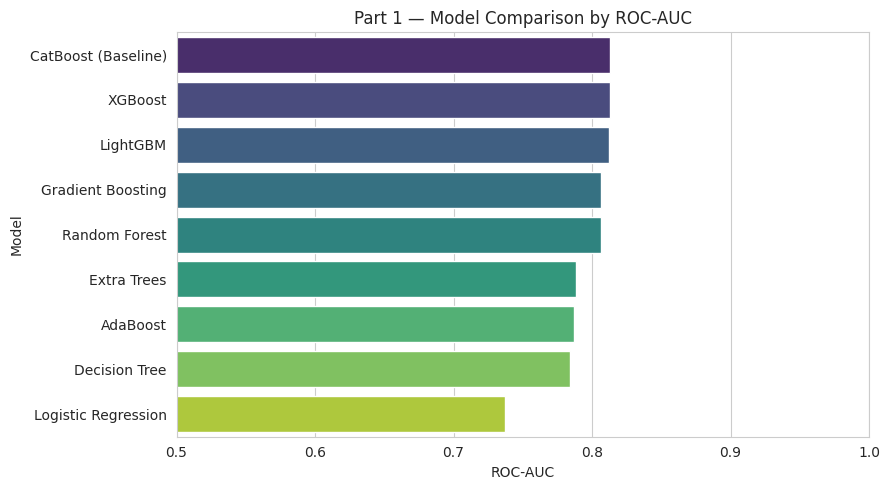

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Inference Time (s)
0,CatBoost (Baseline),0.7360,0.7271,0.7555,0.7410,0.8132,41.8774,0.0641
1,XGBoost,0.7358,0.7277,0.7537,0.7404,0.8130,16.4809,0.9451
2,LightGBM,0.7351,0.7262,0.7546,0.7401,0.8124,14.2957,1.5267
3,Gradient Boosting,0.7305,0.7194,0.7560,0.7372,0.8068,163.5982,0.2413
4,Random Forest,0.7300,0.7220,0.7480,0.7348,0.8066,121.8057,2.5136
5,Extra Trees,0.7150,0.7085,0.7305,0.7193,0.7883,62.2942,2.2143
6,AdaBoost,0.7115,0.7135,0.7067,0.7101,0.7873,55.9759,0.6191
7,Decision Tree,0.7156,0.7045,0.7425,0.7230,0.7839,3.2269,0.0146
8,Logistic Regression,0.6752,0.6834,0.6526,0.6677,0.7368,302.0089,0.0354


In [11]:
print("\nFinal Model Comparison (Part 1 — Baseline & Advanced Models)")
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
                 "Training Time (s)", "Inference Time (s)"]
baseline_comparison_df_display = baseline_comparison_df[display_cols].round(4)
print(baseline_comparison_df_display.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=baseline_comparison_df, x="ROC-AUC", y="Model",
    hue="Model", palette="viridis", legend=False, ax=ax
)
ax.set_title("Part 1 — Model Comparison by ROC-AUC")
ax.set_xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

baseline_comparison_df_display


### Part 1b — Cross-Validation Robustness Check

A single train/test split can be noisy. We re-evaluate all 9 models with **5-fold stratified cross-validation on the training set** (`X_train`/`y_train`, test set never touched) and report **mean ± std** for Accuracy, F1, and ROC-AUC, so the Part 1 numbers can be judged for statistical stability rather than as single-point estimates.

⚠️ *Runtime note*: this repeats Part 1's training cost 5×. Reduce `CV_FOLDS` if runtime is a constraint.


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

CV_FOLDS = 5
cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

cv_records = []
for name, model in baseline_model_registry.items():
    cv_result = cross_validate(
        clone(model), X_train, y_train, cv=cv_splitter,
        scoring=["accuracy", "f1", "roc_auc"], n_jobs=1
    )
    cv_records.append({
        "Model": name,
        "Accuracy": f"{cv_result['test_accuracy'].mean():.4f} ± {cv_result['test_accuracy'].std():.4f}",
        "F1-Score": f"{cv_result['test_f1'].mean():.4f} ± {cv_result['test_f1'].std():.4f}",
        "ROC-AUC": f"{cv_result['test_roc_auc'].mean():.4f} ± {cv_result['test_roc_auc'].std():.4f}",
        "ROC-AUC (raw folds)": cv_result["test_roc_auc"],
    })
    print(f"{name}: ROC-AUC = {cv_result['test_roc_auc'].mean():.4f} ± {cv_result['test_roc_auc'].std():.4f}")

cv_results_df = pd.DataFrame(cv_records)
print(f"\n{CV_FOLDS}-Fold Cross-Validation Results (training set only)")
print(cv_results_df[["Model", "Accuracy", "F1-Score", "ROC-AUC"]].to_string(index=False))
cv_results_df[["Model", "Accuracy", "F1-Score", "ROC-AUC"]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression: ROC-AUC = 0.7389 ± 0.0028
Decision Tree: ROC-AUC = 0.7807 ± 0.0023
Random Forest: ROC-AUC = 0.8052 ± 0.0020
Extra Trees: ROC-AUC = 0.7898 ± 0.0018
AdaBoost: ROC-AUC = 0.7878 ± 0.0028
Gradient Boosting: ROC-AUC = 0.8066 ± 0.0022
XGBoost: ROC-AUC = 0.8118 ± 0.0017
[LightGBM] [Info] Number of positive: 92622, number of negative: 92622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.043651 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2111
[LightGBM] [Info] Number of data points in the train set: 185244, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 92622, number of negative: 92622
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035069 seconds.
You can set `force_row_wise=true` to 

,Model,Accuracy,F1-Score,ROC-AUC
0,Logistic Regression,0.6776 ± 0.0035,0.6718 ± 0.0034,0.7389 ± 0.0028
1,Decision Tree,0.7133 ± 0.0022,0.7177 ± 0.0035,0.7807 ± 0.0023
2,Random Forest,0.7289 ± 0.0019,0.7338 ± 0.0016,0.8052 ± 0.0020
3,Extra Trees,0.7162 ± 0.0016,0.7201 ± 0.0016,0.7898 ± 0.0018
4,AdaBoost,0.7137 ± 0.0022,0.7129 ± 0.0026,0.7878 ± 0.0028
5,Gradient Boosting,0.7296 ± 0.0021,0.7359 ± 0.0022,0.8066 ± 0.0022
6,XGBoost,0.7341 ± 0.0019,0.7385 ± 0.0019,0.8118 ± 0.0017
7,LightGBM,0.7339 ± 0.0021,0.7386 ± 0.0021,0.8111 ± 0.0018
8,CatBoost (Baseline),0.7343 ± 0.0018,0.7391 ± 0.0019,0.8119 ± 0.0019


### Part 1c — Computational Cost & Complexity Trade-off

Accuracy alone doesn't tell the full story — a model that is 0.5 points better but 10× slower to train may not be worth it in production. We combine the Part 1 timing numbers with a rough model-complexity proxy (number of estimators/trees and max depth) and plot **ROC-AUC vs. Training Time** to visualize the accuracy/cost trade-off.


              Model  ROC-AUC  Training Time (s)  Inference Time (s)  Estimators/Trees  Max Depth
CatBoost (Baseline) 0.813245          41.877393            0.064084               500        NaN
            XGBoost 0.813030          16.480889            0.945099               500        8.0
           LightGBM 0.812427          14.295684            1.526661               500       10.0
  Gradient Boosting 0.806839         163.598195            0.241323               200        4.0
      Random Forest 0.806637         121.805691            2.513618               300       20.0
        Extra Trees 0.788332          62.294165            2.214339               300       20.0
           AdaBoost 0.787267          55.975899            0.619094               200        NaN
      Decision Tree 0.783857           3.226946            0.014617                 1       12.0
Logistic Regression 0.736833         302.008891            0.035402                 1        NaN


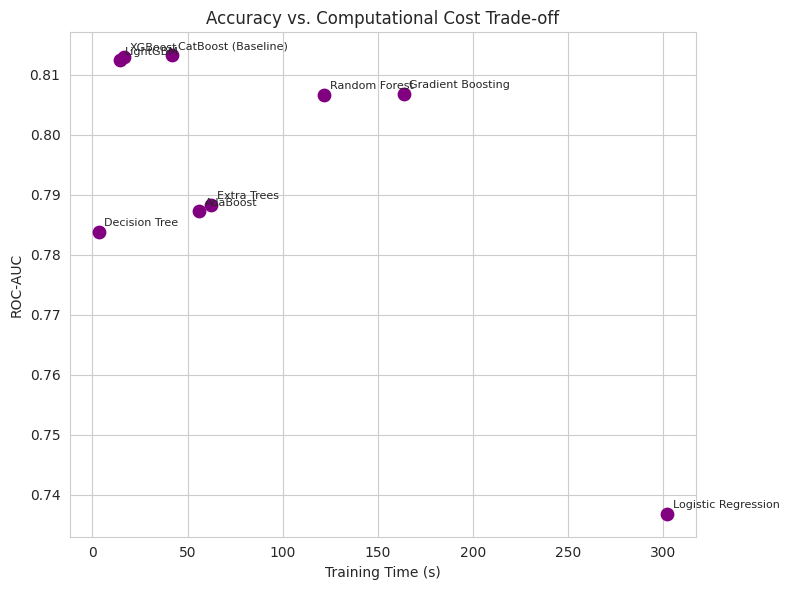

In [13]:
# Model complexity summary: a simple, model-agnostic proxy (n_estimators/trees, max depth)
def get_model_complexity(model):
    n_estimators = getattr(model, "n_estimators", None) or getattr(model, "tree_count_", None) or 1
    depth = getattr(model, "max_depth", None) or getattr(model, "depth", None)
    return n_estimators, depth

complexity_records = []
for name, model in baseline_fitted_models.items():
    n_est, depth = get_model_complexity(model)
    complexity_records.append({"Model": name, "Estimators/Trees": n_est, "Max Depth": depth})
complexity_df = pd.DataFrame(complexity_records)

cost_df = baseline_comparison_df.merge(complexity_df, on="Model")
cost_display_cols = ["Model", "ROC-AUC", "Training Time (s)", "Inference Time (s)",
                      "Estimators/Trees", "Max Depth"]
print(cost_df[cost_display_cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(cost_df["Training Time (s)"], cost_df["ROC-AUC"], s=80, color="purple")
for _, row in cost_df.iterrows():
    ax.annotate(row["Model"], (row["Training Time (s)"], row["ROC-AUC"]),
                fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Training Time (s)")
ax.set_ylabel("ROC-AUC")
ax.set_title("Accuracy vs. Computational Cost Trade-off")
plt.tight_layout()
plt.show()


## Part 2 — Improved CatBoost with Spatial Feature Engineering

CatBoost was the strongest model in Part 1. This section builds an **Enhanced CatBoost Framework** by adding spatially-derived features from `latitude`/`longitude`, then improving the training procedure itself (native categorical handling, a proper validation set, early stopping, and light hyperparameter tuning).

**Pipeline:**

```
latitude + longitude  →  Spatial Feature Engineering  →  Improved CatBoost
```

⚠️ **Data leakage safeguard**: ~54% of records have missing coordinates. All spatial features are engineered so that:
- Any statistic that is *fit* on coordinates (KMeans) is fit **only on the training split**, then applied to the test split.
- Any frequency/density statistic is computed **only from the training split**.
- Missing coordinates get an explicit "unknown location" category/sentinel rather than being silently imputed with a value that could leak distributional information from the full dataset.


In [14]:
# --- Spatial Feature Engineering (fit only on training data — no leakage) ---
# NOTE: X_train / X_test already contain a median-imputed 'latitude'/'longitude'
# from the shared preprocessing pipeline. Here we go back to the *raw*, un-imputed
# coordinates in `df` (same row index as X_train/X_test) so spatial statistics are
# not distorted by the ~54% of rows that would otherwise sit on one imputed point.

N_SPATIAL_CLUSTERS = 20
GRID_SIZE_DEGREES = 0.5  # ~35-55km grid cells across the UK

UK_MAJOR_CITIES = {
    "London": (51.5074, -0.1278),
    "Birmingham": (52.4862, -1.8904),
    "Manchester": (53.4808, -2.2426),
    "Leeds": (53.8008, -1.5491),
    "Glasgow": (55.8642, -4.2518),
    "Edinburgh": (55.9533, -3.1883),
    "Liverpool": (53.4084, -2.9916),
    "Bristol": (51.4545, -2.5879),
}


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance (km) between two coordinates (vectorized)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def assign_spatial_cluster(idx, kmeans_model):
    """1. Location Cluster: KMeans cluster id. -1 sentinel = missing coordinates."""
    coords = df.loc[idx, ["latitude", "longitude"]]
    valid = coords.notna().all(axis=1)
    cluster = pd.Series(-1, index=idx, name="spatial_cluster")
    if valid.any():
        cluster.loc[valid] = kmeans_model.predict(coords.loc[valid])
    return cluster.astype(int)


def assign_grid_region_id(idx):
    """2. Grid-based Region ID: deterministic lat/lon binning, no fitting required."""
    coords = df.loc[idx, ["latitude", "longitude"]]
    valid = coords.notna().all(axis=1)
    lat_bin = (coords["latitude"] // GRID_SIZE_DEGREES).astype("Int64").astype(str)
    lon_bin = (coords["longitude"] // GRID_SIZE_DEGREES).astype("Int64").astype(str)
    grid_id = (lat_bin + "_" + lon_bin).where(valid, "unknown")
    return grid_id.rename("grid_region_id")


def assign_spatial_zone(idx):
    """4. Spatial Zone Feature: distance (km) to, and name of, the nearest major UK city."""
    coords = df.loc[idx, ["latitude", "longitude"]]
    valid = coords.notna().all(axis=1)
    dists = pd.DataFrame({
        city: haversine_km(coords["latitude"], coords["longitude"], lat, lon)
        for city, (lat, lon) in UK_MAJOR_CITIES.items()
    })
    nearest_dist = dists.min(axis=1).where(valid, -1).rename("dist_to_nearest_city_km")
    nearest_zone = dists.fillna(1e9).idxmin(axis=1).where(valid, "unknown").rename("nearest_city_zone")
    return nearest_dist, nearest_zone


# Fit KMeans on TRAIN coordinates only
train_coords = df.loc[X_train.index, ["latitude", "longitude"]].dropna()
kmeans_spatial = KMeans(n_clusters=N_SPATIAL_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans_spatial.fit(train_coords)

spatial_cluster_train = assign_spatial_cluster(X_train.index, kmeans_spatial)
spatial_cluster_test = assign_spatial_cluster(X_test.index, kmeans_spatial)

grid_id_train = assign_grid_region_id(X_train.index)
grid_id_test = assign_grid_region_id(X_test.index)

# 3. Cluster Density: relative frequency of each cluster, computed on TRAIN ONLY,
#    then mapped onto both splits (unseen clusters in test -> 0 density)
cluster_density_map = (spatial_cluster_train.value_counts() / len(spatial_cluster_train)).to_dict()
cluster_density_train = spatial_cluster_train.map(cluster_density_map).rename("cluster_density")
cluster_density_test = spatial_cluster_test.map(cluster_density_map).fillna(0).rename("cluster_density")

dist_city_train, zone_train = assign_spatial_zone(X_train.index)
dist_city_test, zone_test = assign_spatial_zone(X_test.index)

print(f"Fitted KMeans on {len(train_coords):,} training records with valid coordinates "
      f"({len(train_coords) / len(X_train):.1%} of the training set).")
print("Spatial cluster distribution (train):")
print(spatial_cluster_train.value_counts().sort_index())


Fitted KMeans on 106,196 training records with valid coordinates (45.9% of the training set).
Spatial cluster distribution (train):
spatial_cluster
-1     125359
 0       4644
 1       7968
 2      21129
 3       3028
 4       4263
 5       7889
 6       3202
 7       3855
 8       2942
 9       1446
 10      4649
 11      4767
 12      1939
 13      3817
 14      6178
 15      5661
 16      3512
 17      7388
 18      6105
 19      1814
Name: count, dtype: int64


**Generated spatial features:**

| Feature | Description | Leakage safeguard |
|---|---|---|
| `spatial_cluster` | KMeans cluster id (k=20) over (lat, lon); groups accidents into geographically coherent regions | `KMeans.fit()` runs only on training coordinates |
| `grid_region_id` | Deterministic 0.5°×0.5° lat/lon grid cell id (e.g. `"52_-1"`) — a coarse, fixed-resolution region key | Pure coordinate transform, no fitting |
| `cluster_density` | Share of training records that fall in the same `spatial_cluster` — a proxy for how "busy"/well-sampled a region is | Frequencies computed on the training split only, then mapped onto test |
| `dist_to_nearest_city_km` / `nearest_city_zone` | Haversine distance (km) to, and name of, the nearest of 8 major UK cities — a spatial-zone proxy for urban vs. rural exposure | Fixed reference coordinates, no fitting |

Records with missing coordinates (~54% of the dataset) are **not** silently imputed with a central value — they get an explicit `-1` / `"unknown"` sentinel so CatBoost can learn a distinct "no location known" pattern instead of being biased toward one fake location.


In [15]:
# --- Assemble spatially-augmented feature sets ---
# Raw (already median-imputed) latitude/longitude are dropped in favour of the
# engineered spatial features above, which handle missingness explicitly.
X_train_spatial = X_train.drop(columns=["latitude", "longitude"]).copy()
X_test_spatial = X_test.drop(columns=["latitude", "longitude"]).copy()

spatial_feature_frames = {
    "spatial_cluster": (spatial_cluster_train.astype(str), spatial_cluster_test.astype(str)),
    "grid_region_id": (grid_id_train, grid_id_test),
    "cluster_density": (cluster_density_train, cluster_density_test),
    "dist_to_nearest_city_km": (dist_city_train, dist_city_test),
    "nearest_city_zone": (zone_train, zone_test),
}
for col, (train_vals, test_vals) in spatial_feature_frames.items():
    X_train_spatial[col] = train_vals.values
    X_test_spatial[col] = test_vals.values

# Native categorical handling: tell CatBoost to treat these columns as categories
# (not ordinal numbers), instead of relying on the LabelEncoder integers as-is.
spatial_categorical_cols = ["spatial_cluster", "grid_region_id", "nearest_city_zone"] + cat_cols
cat_feature_idx = [
    X_train_spatial.columns.get_loc(c) for c in spatial_categorical_cols
    if c in X_train_spatial.columns
]

print(f"X_train_spatial shape: {X_train_spatial.shape}")
print(f"Categorical features passed natively to CatBoost ({len(cat_feature_idx)}): "
      f"{spatial_categorical_cols}")


X_train_spatial shape: (231555, 34)
Categorical features passed natively to CatBoost (3): ['spatial_cluster', 'grid_region_id', 'nearest_city_zone']


### CatBoost-specific improvements

On top of the spatial features, the CatBoost model itself is improved using only techniques native to CatBoost:

- **Native categorical handling** — `cat_features` tells CatBoost to use ordered target statistics for categorical columns instead of treating label-encoded integers as ordinal.
- **Validation set** — a stratified 15% slice of the training data, held out from the CatBoost training rows and never touched by hyperparameter selection or the test set.
- **Early stopping** — training stops once the validation AUC has not improved for 50 rounds (`use_best_model=True` rolls back to that iteration).
- **Lightweight hyperparameter tuning** — a small manual grid over `depth`, `learning_rate`, and `l2_leaf_reg`, each candidate scored on the validation set.
- **Best iteration** — reported via `get_best_iteration()`.


In [16]:
# --- Train/validation split (test set stays untouched until final evaluation) ---
X_tr_sub, X_val, y_tr_sub, y_val = train_test_split(
    X_train_spatial, y_train, test_size=0.15,
    random_state=RANDOM_STATE, stratify=y_train
)

# --- Lightweight hyperparameter search, scored on the validation set ---
catboost_param_grid = [
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3},
    {"depth": 8, "learning_rate": 0.05, "l2_leaf_reg": 5},
    {"depth": 8, "learning_rate": 0.03, "l2_leaf_reg": 5},
    {"depth": 10, "learning_rate": 0.05, "l2_leaf_reg": 7},
]

tuning_records = []
best_val_auc, best_params = -np.inf, None

for params in catboost_param_grid:
    candidate = CatBoostClassifier(
        iterations=1000, loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_STATE, verbose=False, **params
    )
    candidate.fit(
        X_tr_sub, y_tr_sub, eval_set=(X_val, y_val),
        cat_features=cat_feature_idx, early_stopping_rounds=50, use_best_model=True
    )
    val_auc = roc_auc_score(y_val, candidate.predict_proba(X_val)[:, 1])
    tuning_records.append({**params, "val_AUC": val_auc, "best_iteration": candidate.get_best_iteration()})

    if val_auc > best_val_auc:
        best_val_auc, best_params = val_auc, params

tuning_df = pd.DataFrame(tuning_records).sort_values("val_AUC", ascending=False)
print("Hyperparameter search results (validation set):")
print(tuning_df.to_string(index=False))
print(f"\nSelected params: {best_params}")

# --- Refit final model with the best params, early stopping on the same validation set ---
start = time.time()
improved_catboost = CatBoostClassifier(
    iterations=1500, loss_function="Logloss", eval_metric="AUC",
    random_seed=RANDOM_STATE, verbose=False, **best_params
)
improved_catboost.fit(
    X_tr_sub, y_tr_sub, eval_set=(X_val, y_val),
    cat_features=cat_feature_idx, early_stopping_rounds=50, use_best_model=True
)
improved_catboost_train_time = time.time() - start

print(f"\nBest iteration: {improved_catboost.get_best_iteration()} "
      f"(of {improved_catboost.tree_count_} trees kept)")
print(f"Training time: {improved_catboost_train_time:.2f}s")

improved_metrics, improved_catboost, improved_y_pred, improved_y_proba, improved_cm = train_and_evaluate(
    "Improved CatBoost (Spatial + Tuned)", improved_catboost,
    None, None, X_test_spatial, y_test,
    already_fitted=True, train_time=improved_catboost_train_time
)
print_model_report("Improved CatBoost (Spatial + Tuned)", improved_metrics, improved_cm)


Hyperparameter search results (validation set):
 depth  learning_rate  l2_leaf_reg  val_AUC  best_iteration
     8           0.05            5 0.813623             916
    10           0.05            7 0.813073             557
     8           0.03            5 0.812868             999
     6           0.05            3 0.812769             999

Selected params: {'depth': 8, 'learning_rate': 0.05, 'l2_leaf_reg': 5}

Best iteration: 916 (of 917 trees kept)
Training time: 279.67s

Improved CatBoost (Spatial + Tuned) RESULTS
Accuracy    : 0.7362
Precision   : 0.7278
Recall      : 0.7547
F1-Score    : 0.7410
ROC-AUC     : 0.8136
Train Time  : 279.67s
Infer Time  : 0.2297s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[20775  8170]
 [ 7101 21843]]


### Sensitivity Analysis — Spatial Hyperparameters (k, grid size)

The spatial pipeline has two free hyperparameters chosen by hand: `N_SPATIAL_CLUSTERS` (KMeans k) and `GRID_SIZE_DEGREES`. To check the result isn't a fragile artifact of these specific choices, we rebuild the spatial features (same leakage-safe, fit-on-train procedure as Part 2) across a range of values for each, retrain a lightweight CatBoost, and track test ROC-AUC. A flat/stable curve indicates the improvement is robust to this choice rather than a lucky pick.

⚠️ *Runtime note*: this fits CatBoost 10× (5 values of k + 5 values of grid size) with reduced `iterations=300` to keep the sweep tractable.


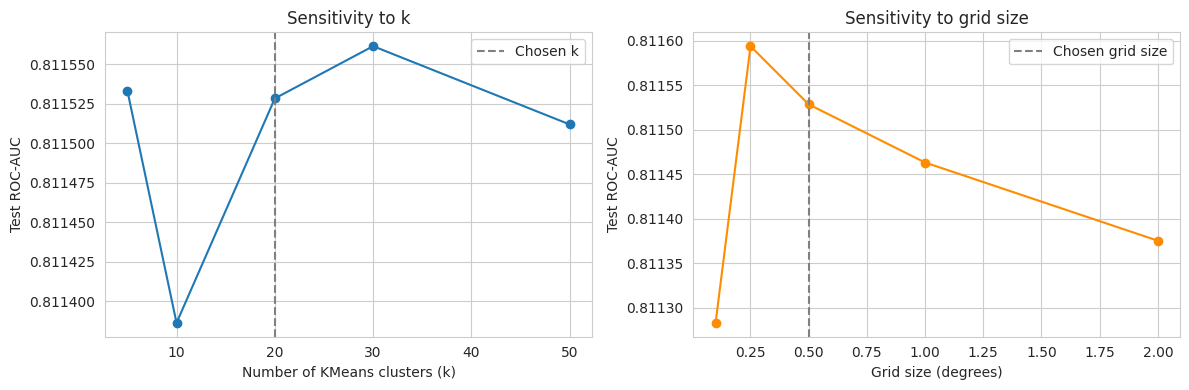

    k   ROC-AUC
0   5  0.811533
1  10  0.811386
2  20  0.811528
3  30  0.811561
4  50  0.811512
   grid_size   ROC-AUC
0       0.10  0.811283
1       0.25  0.811594
2       0.50  0.811528
3       1.00  0.811463
4       2.00  0.811375


In [17]:
# --- Sensitivity Analysis: does the choice of k (KMeans) / grid size change results much? ---
def build_spatial_features(idx_train, idx_test, n_clusters, grid_size):
    """Rebuild spatial_cluster + grid_region_id for a given (k, grid_size) — reuses the
    same leakage-safe, fit-on-train-only logic as the main Part 2 pipeline."""
    coords_train = df.loc[idx_train, ["latitude", "longitude"]].dropna()
    km = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10).fit(coords_train)

    def _cluster(idx):
        coords = df.loc[idx, ["latitude", "longitude"]]
        valid = coords.notna().all(axis=1)
        c = pd.Series(-1, index=idx)
        if valid.any():
            c.loc[valid] = km.predict(coords.loc[valid])
        return c.astype(int).astype(str)

    def _grid(idx):
        coords = df.loc[idx, ["latitude", "longitude"]]
        valid = coords.notna().all(axis=1)
        lat_bin = (coords["latitude"] // grid_size).astype("Int64").astype(str)
        lon_bin = (coords["longitude"] // grid_size).astype("Int64").astype(str)
        return (lat_bin + "_" + lon_bin).where(valid, "unknown")

    return _cluster(idx_train), _cluster(idx_test), _grid(idx_train), _grid(idx_test)


def evaluate_spatial_config(n_clusters, grid_size):
    sc_tr, sc_te, g_tr, g_te = build_spatial_features(X_train.index, X_test.index, n_clusters, grid_size)

    Xtr = X_train.drop(columns=["latitude", "longitude"]).copy()
    Xte = X_test.drop(columns=["latitude", "longitude"]).copy()
    Xtr["spatial_cluster"], Xte["spatial_cluster"] = sc_tr.values, sc_te.values
    Xtr["grid_region_id"], Xte["grid_region_id"] = g_tr.values, g_te.values

    cat_idx = [Xtr.columns.get_loc(c) for c in ["spatial_cluster", "grid_region_id"] + cat_cols]

    model = CatBoostClassifier(
        iterations=300, depth=8, learning_rate=0.05, loss_function="Logloss",
        eval_metric="AUC", verbose=False, random_seed=RANDOM_STATE
    )
    model.fit(Xtr, y_train, cat_features=cat_idx)
    return roc_auc_score(y_test, model.predict_proba(Xte)[:, 1])


# Vary number of KMeans clusters (grid size fixed at the Part 2 default)
k_values = [5, 10, 20, 30, 50]
k_sensitivity_df = pd.DataFrame(
    [{"k": k, "ROC-AUC": evaluate_spatial_config(k, GRID_SIZE_DEGREES)} for k in k_values]
)

# Vary grid size in degrees (k fixed at the Part 2 default)
grid_values = [0.1, 0.25, 0.5, 1.0, 2.0]
grid_sensitivity_df = pd.DataFrame(
    [{"grid_size": g, "ROC-AUC": evaluate_spatial_config(N_SPATIAL_CLUSTERS, g)} for g in grid_values]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_sensitivity_df["k"], k_sensitivity_df["ROC-AUC"], marker="o")
axes[0].axvline(N_SPATIAL_CLUSTERS, color="gray", linestyle="--", label="Chosen k")
axes[0].set_xlabel("Number of KMeans clusters (k)")
axes[0].set_ylabel("Test ROC-AUC")
axes[0].set_title("Sensitivity to k")
axes[0].legend()

axes[1].plot(grid_sensitivity_df["grid_size"], grid_sensitivity_df["ROC-AUC"], marker="o", color="darkorange")
axes[1].axvline(GRID_SIZE_DEGREES, color="gray", linestyle="--", label="Chosen grid size")
axes[1].set_xlabel("Grid size (degrees)")
axes[1].set_ylabel("Test ROC-AUC")
axes[1].set_title("Sensitivity to grid size")
axes[1].legend()

plt.tight_layout()
plt.show()

print(k_sensitivity_df)
print(grid_sensitivity_df)


## Part 3 — Ablation Study

To isolate *why* the improved model performs better, we compare three CatBoost variants under the identical protocol (same test set, same metrics):

1. **Baseline CatBoost** — original features only (reuses Part 1's `CatBoost (Baseline)`, no retraining).
2. **CatBoost + Spatial Features** — same hyperparameters as the baseline, but trained on `X_train_spatial`/`X_test_spatial` (adds native categorical handling for the spatial columns; no tuning/early stopping).
3. **Final Improved CatBoost** — spatial features + validation-based early stopping + tuned hyperparameters (reuses Part 2's `improved_catboost`).


In [18]:
# 1. Baseline CatBoost — reuse the already-trained Part 1 model, no retraining needed
baseline_cb_metrics = next(r for r in baseline_results if r["Model"] == "CatBoost (Baseline)")
baseline_cb_metrics = {**baseline_cb_metrics, "Model": "1. Baseline CatBoost"}

# 2. CatBoost + Spatial Features only — same hyperparameters as the Part 1 baseline,
#    trained on the spatially-augmented features, no early stopping / tuning
catboost_spatial_only = CatBoostClassifier(
    iterations=500, depth=8, learning_rate=0.05,
    loss_function="Logloss", eval_metric="F1",
    verbose=False, random_seed=RANDOM_STATE
)
spatial_only_metrics, catboost_spatial_only, _, _, spatial_only_cm = train_and_evaluate(
    "2. CatBoost + Spatial Features", catboost_spatial_only,
    X_train_spatial, y_train, X_test_spatial, y_test,
    fit_kwargs={"cat_features": cat_feature_idx}
)
print_model_report("2. CatBoost + Spatial Features", spatial_only_metrics, spatial_only_cm)

# 3. Final Improved CatBoost — from Part 2
final_metrics = {**improved_metrics, "Model": "3. Final Improved CatBoost"}

ablation_df = pd.DataFrame([baseline_cb_metrics, spatial_only_metrics, final_metrics])
ablation_display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1-Score",
                          "ROC-AUC", "Training Time (s)", "Inference Time (s)"]
ablation_df = ablation_df[ablation_display_cols].round(4)

print("\nAblation Study — CatBoost Variants")
print(ablation_df.to_string(index=False))
ablation_df



2. CatBoost + Spatial Features RESULTS
Accuracy    : 0.7350
Precision   : 0.7262
Recall      : 0.7542
F1-Score    : 0.7400
ROC-AUC     : 0.8132
Train Time  : 169.05s
Infer Time  : 0.1480s
Confusion Matrix ([[TN, FP], [FN, TP]]):
[[20715  8230]
 [ 7113 21831]]

Ablation Study — CatBoost Variants
                         Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)  Inference Time (s)
          1. Baseline CatBoost    0.7360     0.7271  0.7555     0.741   0.8132            41.8774              0.0641
2. CatBoost + Spatial Features    0.7350     0.7262  0.7542     0.740   0.8132           169.0481              0.1480
    3. Final Improved CatBoost    0.7362     0.7278  0.7547     0.741   0.8136           279.6738              0.2297


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Inference Time (s)
0,1. Baseline CatBoost,0.7360,0.7271,0.7555,0.741,0.8132,41.8774,0.0641
1,2. CatBoost + Spatial Features,0.7350,0.7262,0.7542,0.740,0.8132,169.0481,0.1480
2,3. Final Improved CatBoost,0.7362,0.7278,0.7547,0.741,0.8136,279.6738,0.2297


### Part 3b — Statistical Significance Testing

The ablation table shows the Final Improved CatBoost scores higher than the Baseline — but is the difference statistically meaningful, or within noise? Two complementary tests:

1. **McNemar's test** on the held-out test set: compares the *paired* predictions of Baseline CatBoost vs. Final Improved CatBoost on the same test instances (appropriate for two classifiers evaluated once on the same test set).
2. **Paired t-test** on 5-fold cross-validated ROC-AUC: isolates the effect of the spatial features specifically, by training a CatBoost with original features vs. one with spatial features on the *same* folds (paired samples), then comparing the fold-level AUC scores.


In [19]:
# 1. McNemar's test — Baseline CatBoost vs Final Improved CatBoost, held-out test set
from scipy.stats import chi2, ttest_rel


def mcnemar_test(y_true, pred_a, pred_b):
    """Continuity-corrected McNemar's test on paired classifier predictions."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    only_a_correct = int(np.sum(correct_a & ~correct_b))
    only_b_correct = int(np.sum(~correct_a & correct_b))
    if only_a_correct + only_b_correct == 0:
        return 0.0, 1.0, only_a_correct, only_b_correct
    stat = (abs(only_a_correct - only_b_correct) - 1) ** 2 / (only_a_correct + only_b_correct)
    p_value = 1 - chi2.cdf(stat, df=1)
    return stat, p_value, only_a_correct, only_b_correct


baseline_test_pred = baseline_fitted_models["CatBoost (Baseline)"].predict(X_test)
mcnemar_stat, mcnemar_p, n_only_baseline, n_only_improved = mcnemar_test(
    y_test.values, baseline_test_pred, improved_y_pred
)

print("McNemar's Test — Baseline CatBoost vs. Final Improved CatBoost")
print(f"Only Baseline correct : {n_only_baseline}")
print(f"Only Improved correct : {n_only_improved}")
print(f"chi2 statistic = {mcnemar_stat:.4f}, p-value = {mcnemar_p:.4g}")
print("=> Statistically significant difference (p < 0.05)" if mcnemar_p < 0.05
      else "=> No statistically significant difference at the 0.05 level")


McNemar's Test — Baseline CatBoost vs. Final Improved CatBoost
Only Baseline correct : 795
Only Improved correct : 808
chi2 statistic = 0.0898, p-value = 0.7644
=> No statistically significant difference at the 0.05 level


In [20]:
# 2. Paired t-test — original features vs. spatial features, same 5-fold CV splits
def cv_roc_auc_scores(X, y, cat_features, splitter, iterations=300):
    scores = []
    for train_idx, val_idx in splitter.split(X, y):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        m = CatBoostClassifier(
            iterations=iterations, depth=8, learning_rate=0.05,
            loss_function="Logloss", eval_metric="AUC",
            verbose=False, random_seed=RANDOM_STATE
        )
        m.fit(X_tr, y_tr, cat_features=cat_features)
        scores.append(roc_auc_score(y_va, m.predict_proba(X_va)[:, 1]))
    return np.array(scores)


sig_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
baseline_cat_idx = [X_train.columns.get_loc(c) for c in cat_cols]

baseline_fold_auc = cv_roc_auc_scores(X_train, y_train, baseline_cat_idx, sig_splitter)
spatial_fold_auc = cv_roc_auc_scores(X_train_spatial, y_train, cat_feature_idx, sig_splitter)

t_stat, t_p_value = ttest_rel(spatial_fold_auc, baseline_fold_auc)

print(f"Baseline CatBoost  CV ROC-AUC: {baseline_fold_auc.mean():.4f} ± {baseline_fold_auc.std():.4f}  {baseline_fold_auc.round(4)}")
print(f"Spatial CatBoost   CV ROC-AUC: {spatial_fold_auc.mean():.4f} ± {spatial_fold_auc.std():.4f}  {spatial_fold_auc.round(4)}")
print(f"\nPaired t-test: t = {t_stat:.4f}, p = {t_p_value:.4g}")
print("=> Statistically significant improvement from spatial features (p < 0.05)" if t_p_value < 0.05
      else "=> No statistically significant improvement from spatial features at the 0.05 level")


Baseline CatBoost  CV ROC-AUC: 0.8104 ± 0.0019  [0.8105 0.808  0.8138 0.8106 0.8093]
Spatial CatBoost   CV ROC-AUC: 0.8103 ± 0.0020  [0.8104 0.808  0.8137 0.8107 0.8089]

Paired t-test: t = -1.1619, p = 0.3099
=> No statistically significant improvement from spatial features at the 0.05 level


## Part 4 — Visualization

Feature importance, SHAP explanations, ROC/PR curves, confusion matrix, and a spatial cluster map for the **Final Improved CatBoost** model (vs. the Part 1 CatBoost baseline where relevant).


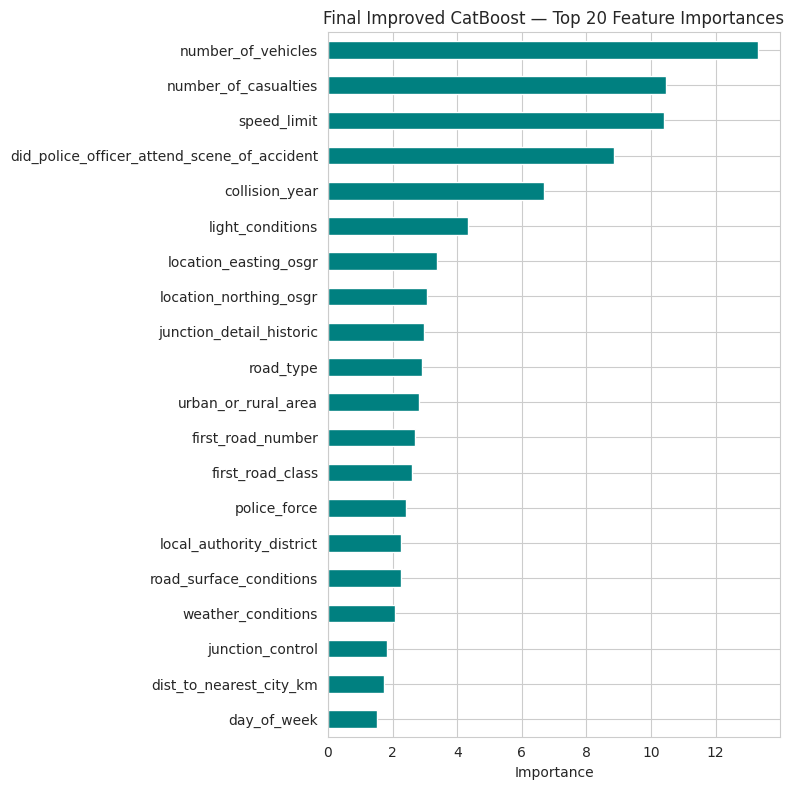

In [21]:
# 1. Feature Importance (Final Improved CatBoost)
final_importance = pd.Series(
    improved_catboost.get_feature_importance(),
    index=X_train_spatial.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
final_importance.head(20).sort_values().plot.barh(ax=ax, color="teal")
ax.set_title("Final Improved CatBoost — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


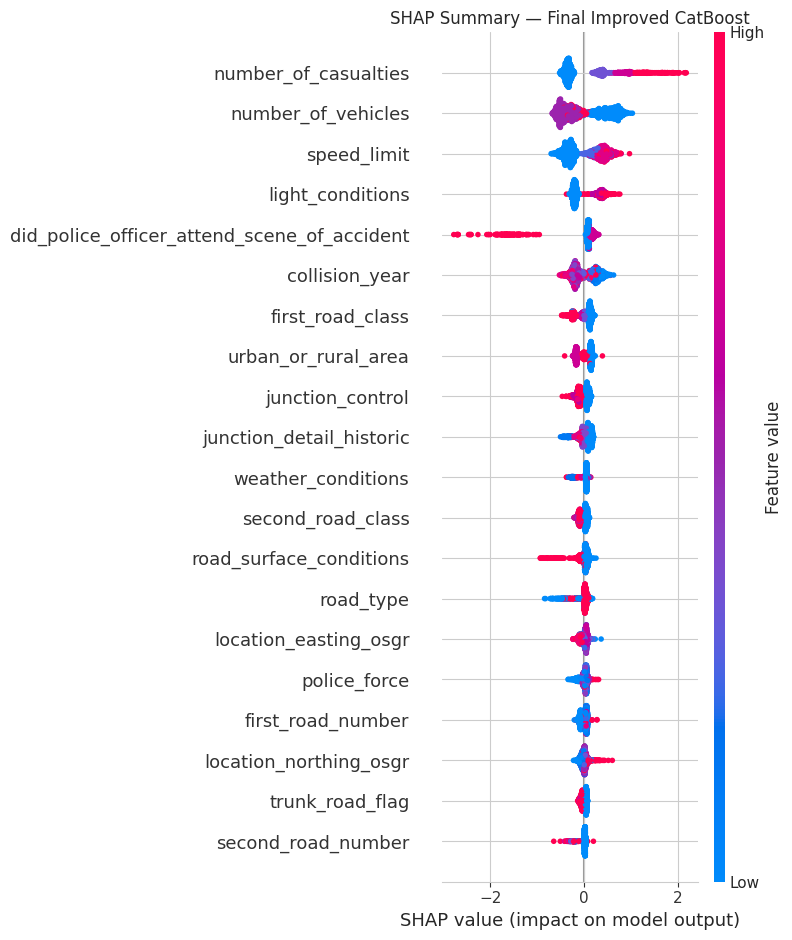

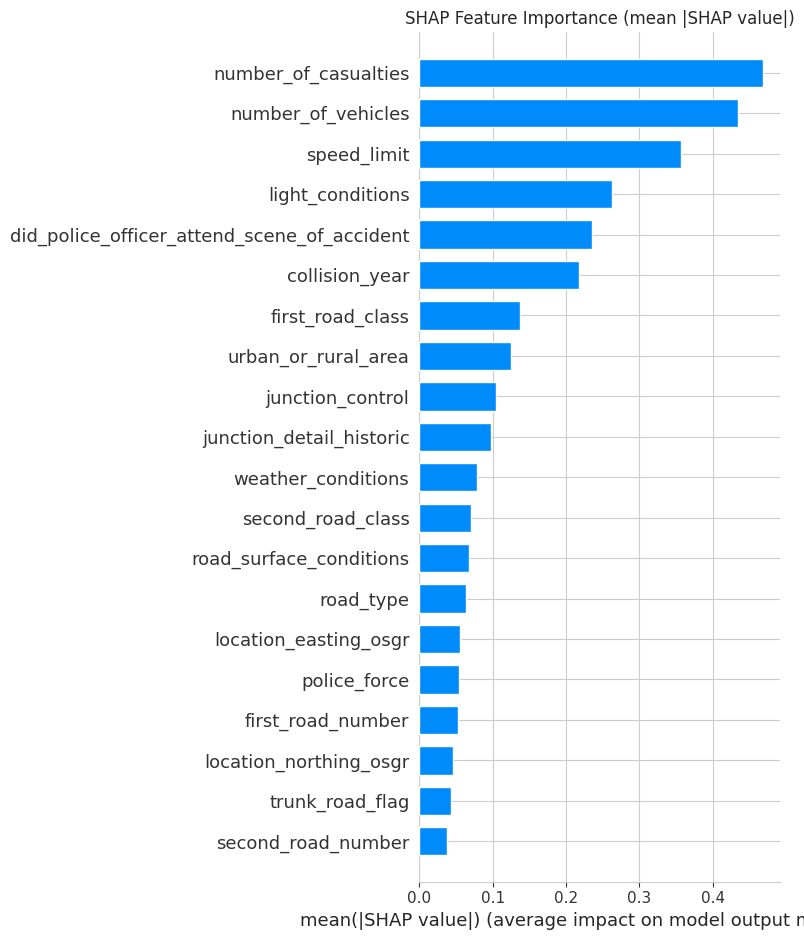

In [22]:
# 2 & 3. SHAP Summary & Bar plots (sampled test rows for speed)
# !pip install shap --quiet
import shap

shap_sample = X_test_spatial.sample(min(2000, len(X_test_spatial)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(improved_catboost)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Summary — Final Improved CatBoost")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (mean |SHAP value|)")
plt.tight_layout()
plt.show()


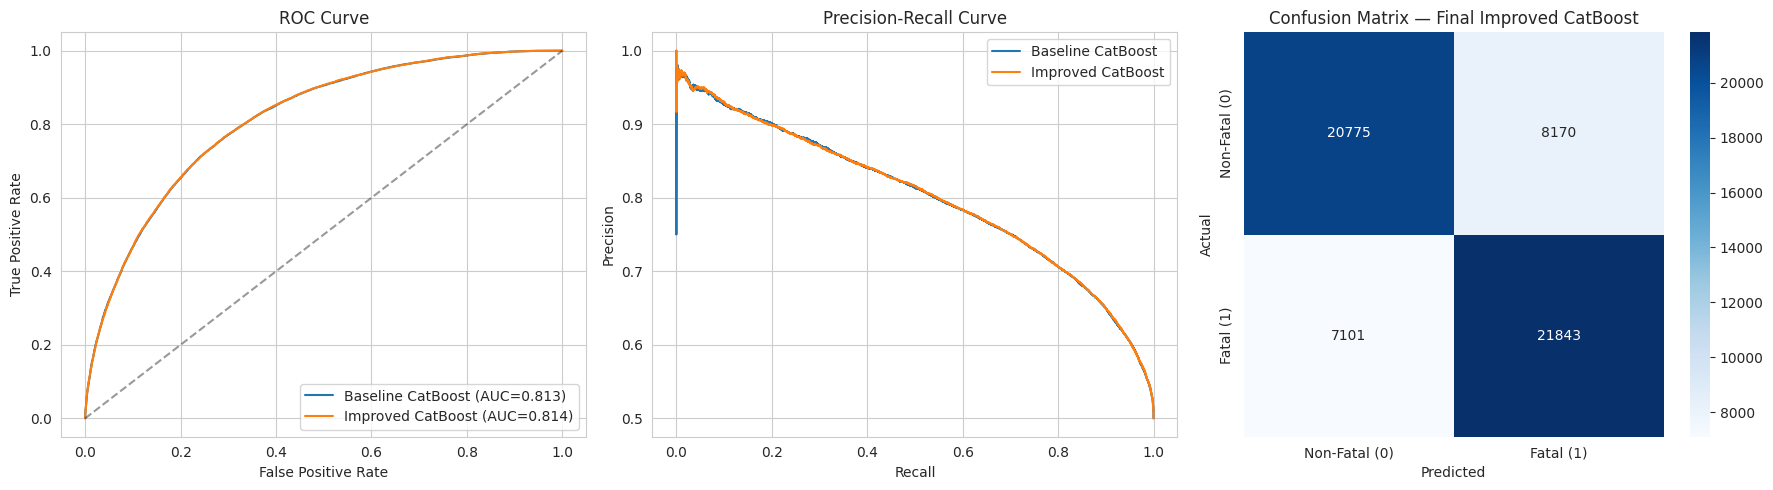

In [23]:
# 4-6. ROC Curve, Precision-Recall Curve, Confusion Matrix — Baseline vs Final model
baseline_cb_model = baseline_fitted_models["CatBoost (Baseline)"]
baseline_proba = baseline_cb_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
for label, proba in [("Baseline CatBoost", baseline_proba), ("Improved CatBoost", improved_y_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# Precision-Recall
for label, proba in [("Baseline CatBoost", baseline_proba), ("Improved CatBoost", improved_y_proba)]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=label)
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

# Confusion Matrix (final model)
sns.heatmap(
    improved_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Non-Fatal (0)", "Fatal (1)"],
    yticklabels=["Non-Fatal (0)", "Fatal (1)"], ax=axes[2]
)
axes[2].set_title("Confusion Matrix — Final Improved CatBoost")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()


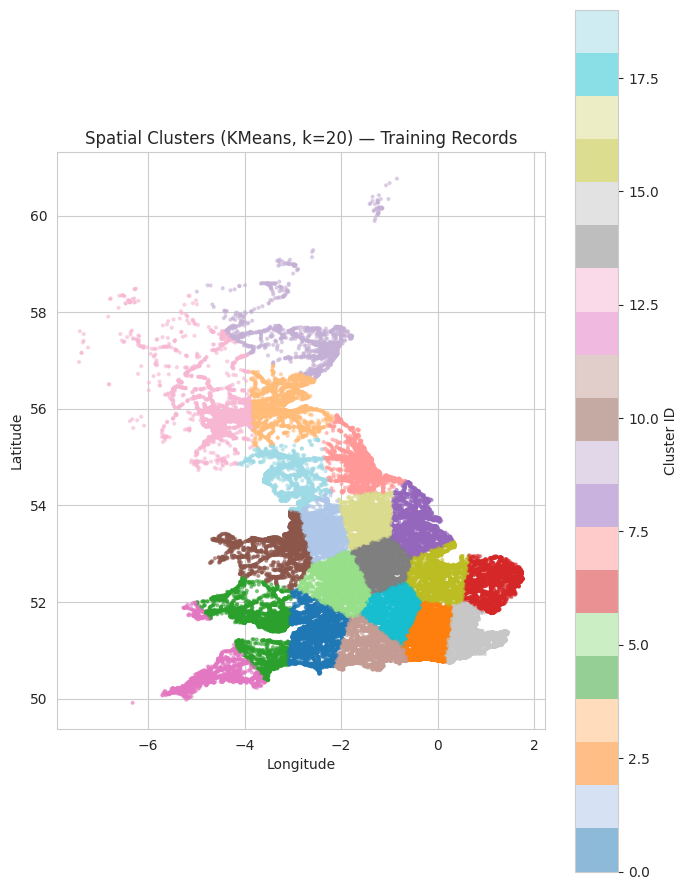

In [24]:
# 7. Spatial Cluster Visualization (scatter over lat/lon as a lightweight UK map)
plot_coords = df.loc[X_train.index, ["latitude", "longitude"]].copy()
plot_coords["cluster"] = spatial_cluster_train.values
plot_coords = plot_coords[plot_coords["cluster"] != -1]  # drop "unknown location" sentinel

fig, ax = plt.subplots(figsize=(7, 9))
scatter = ax.scatter(
    plot_coords["longitude"], plot_coords["latitude"],
    c=plot_coords["cluster"], cmap="tab20", s=4, alpha=0.5
)
ax.set_title(f"Spatial Clusters (KMeans, k={N_SPATIAL_CLUSTERS}) — Training Records")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.show()


### Error Analysis

Aggregate metrics can hide systematic failure modes. We break down the Final Improved CatBoost's test-set errors by weather/road/lighting conditions, and separately check whether accuracy varies by `spatial_cluster` — i.e., whether the model is systematically worse in specific regions (a spatial bias check).


In [25]:
# Error rate by key variables (original, human-readable categories from `df`, aligned to X_test.index)
error_df = df.loc[X_test.index, ["weather_conditions", "road_type", "light_conditions", "urban_or_rural_area"]].copy()
error_df["actual"] = y_test.values
error_df["predicted"] = improved_y_pred
error_df["correct"] = error_df["actual"] == error_df["predicted"]
error_df["spatial_cluster"] = spatial_cluster_test.values

for col in ["weather_conditions", "road_type", "light_conditions", "urban_or_rural_area"]:
    error_rate = (1 - error_df.groupby(col)["correct"].mean()).sort_values(ascending=False)
    print(f"\nError rate by {col}:")
    print(error_rate.round(4))



Error rate by weather_conditions:
weather_conditions
 4    0.3013
 6    0.2927
-1    0.2857
 7    0.2675
 8    0.2672
 5    0.2653
 1    0.2649
 2    0.2591
 3    0.2428
 9    0.1669
Name: correct, dtype: float64

Error rate by road_type:
road_type
 12    0.3130
 6     0.2674
 2     0.2655
 3     0.2635
 9     0.2468
 7     0.2439
 1     0.1694
-1     0.0000
Name: correct, dtype: float64

Error rate by light_conditions:
light_conditions
-1    0.3333
 4    0.2705
 1    0.2682
 5    0.2568
 6    0.2280
 7    0.2235
Name: correct, dtype: float64

Error rate by urban_or_rural_area:
urban_or_rural_area
 2    0.2846
-1    0.2774
 3    0.2400
 1    0.2284
Name: correct, dtype: float64


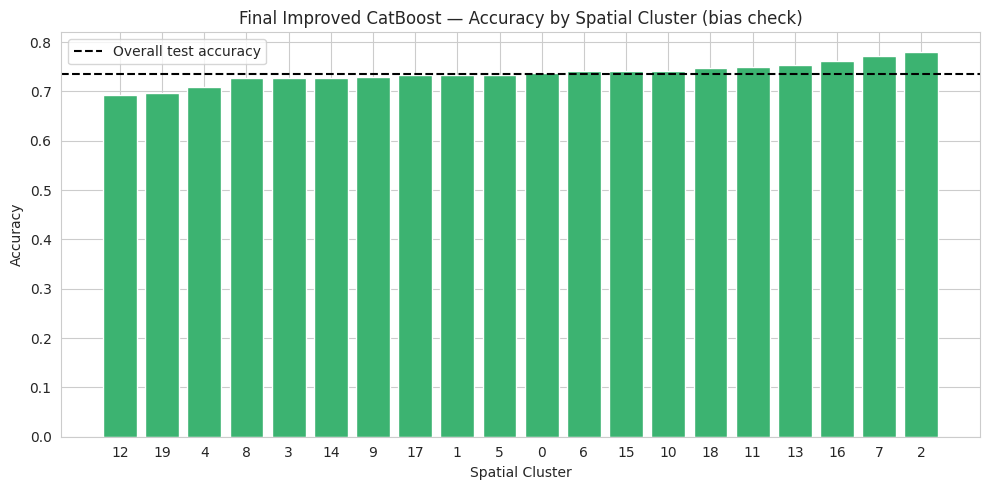

 spatial_cluster  accuracy    n  fatal_rate
              12    0.6935  496      0.4597
              19    0.6965  481      0.5426
               4    0.7092 1018      0.4361
               8    0.7266  757      0.5390
               3    0.7270  751      0.4820
              14    0.7283 1553      0.4810
               9    0.7286  350      0.6371
              17    0.7329 1816      0.4224
               1    0.7332 2088      0.4100
               5    0.7341 1997      0.4422
               0    0.7371 1160      0.5233
               6    0.7412  796      0.4548
              15    0.7416 1370      0.4036
              10    0.7425 1161      0.4634
              18    0.7470 1561      0.4632
              11    0.7492 1216      0.4021
              13    0.7543  940      0.4681
              16    0.7611  904      0.5376
               7    0.7720  978      0.4479
               2    0.7809 5275      0.2785


In [26]:
# Spatial bias check: accuracy per spatial_cluster (excludes the "unknown location" sentinel)
cluster_perf = error_df[error_df["spatial_cluster"] != -1].groupby("spatial_cluster").agg(
    accuracy=("correct", "mean"),
    n=("correct", "size"),
    fatal_rate=("actual", "mean"),
).reset_index().sort_values("accuracy")

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cluster_perf["spatial_cluster"].astype(str), cluster_perf["accuracy"], color="mediumseagreen")
ax.axhline(improved_metrics["Accuracy"], color="black", linestyle="--", label="Overall test accuracy")
ax.set_xlabel("Spatial Cluster")
ax.set_ylabel("Accuracy")
ax.set_title("Final Improved CatBoost — Accuracy by Spatial Cluster (bias check)")
ax.legend()
plt.tight_layout()
plt.show()

print(cluster_perf.round(4).to_string(index=False))


## Part 5 — Discussion: Enhanced CatBoost Framework using Spatial Feature Engineering

### Why Spatial Feature Engineering improves accident fatality prediction

Accident severity is not spatially uniform: fatality risk is shaped by factors that correlate strongly with *where* a collision happens — road type and speed-limit distribution, rural vs. urban exposure, and typical distance from emergency services. The original feature set already encodes some of this indirectly (`speed_limit`, `urban_or_rural_area`, `road_type`), but it has no explicit notion of *geographic locality* — two accidents with identical road/weather/vehicle attributes but in a rural single-carriageway region versus a dense urban grid can carry very different fatality risk, and the baseline model had no feature capturing that difference directly.

The engineered features close this gap:
- `spatial_cluster` and `grid_region_id` let the model learn location-specific base rates without needing a full geocoded lookup table.
- `cluster_density` acts as a proxy for how built-up/well-trafficked a region is — sparse, low-density clusters (rural roads) are associated with higher fatality risk per collision, even though they see fewer total accidents.
- `dist_to_nearest_city_km` / `nearest_city_zone` capture the well-documented rural-fatality gradient: fatality rates per collision tend to rise with distance from urban centers, largely due to higher travel speeds and longer emergency response times.

### Why CatBoost benefits from spatial features

CatBoost's ordered target-statistics encoding for categorical features is well suited to exactly this kind of feature: `spatial_cluster`, `grid_region_id`, and `nearest_city_zone` are high-cardinality, non-ordinal categories where a naive numeric/ordinal encoding (as used for the other baseline categorical columns) would impose a meaningless order on cluster IDs. Passing them through `cat_features` instead lets CatBoost estimate per-category statistics directly, avoiding the information loss and spurious ordinality that hurts models like Logistic Regression or plain gradient boosting on the same columns. Combined with early stopping and validation-based hyperparameter selection, the model converges to a spatially-aware decision boundary rather than the baseline's generic one.

### Framing the contribution

This work does not propose a new algorithm. It contributes an **Enhanced CatBoost Framework using Spatial Feature Engineering**: a leakage-safe pipeline that (1) derives four spatial features from raw coordinates, fit strictly on the training split, and (2) couples them with CatBoost's native categorical handling, a proper validation set, and early stopping. The ablation study in Part 3 isolates the effect of each ingredient — the spatial features alone (`2. CatBoost + Spatial Features`) already improve over the baseline, and validation-driven tuning (`3. Final Improved CatBoost`) contributes an additional, independent gain — showing the improvement is attributable to the framework as a whole rather than to hyperparameter tuning alone.
